In [1]:
import sys

sys.argv = [
    "ipykernel_launcher.py",  
    "--dataset", "CustomAWGN30ES15",  # Ensure value is provided
    "--model", "",
    "--Device", "cpu",
    "--test"  # This is a flag, so no value needed
]

In [2]:
import pickle
import os
import pandas as pd
import numpy as np
import sqlite3
from tqdm import tqdm
import copy

from datetime import datetime, timedelta
from torch.utils.data import Dataset, DataLoader, TensorDataset

import sklearn
from scipy.signal import resample
from src.models import *
from src.utils import *
from main import  load_dataset, backprop

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.dates import DateFormatter

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

def normalize3(a, min_a=None, max_a=None):
    if min_a is None: min_a, max_a = np.min(a, axis=0), np.max(a, axis=0)
    return ((a - min_a) / (max_a - min_a + 0.0001)), min_a, max_a

def denormalize3(a_norm, min_a, max_a):
    return a_norm * (max_a - min_a + 0.0001) + min_a

def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)

def convert_to_windows(data, model):
    windows = []
    w_size = model.n_window
    for i, g in enumerate(data):
        if i >= w_size:
            w = data[i - w_size:i]  # cut
        else:
            w = torch.cat([data[0].repeat(w_size - i, 1), data[0:i]])  # pad
        windows.append(w if 'DTAAD' in model.name or 'Attention' in model.name or 'TranAD' in model.name else w.view(-1))
    return torch.stack(windows)

def load_model(modelname, dims):
    import src.models
    model_class = getattr(src.models, modelname)
    model = model_class(dims).double()
    fname = f'checkpoints/{model.name}_{args.dataset}/model.ckpt'
    if os.path.exists(fname) and (not args.retrain or args.test):
        checkpoint = torch.load(fname, weights_only=False, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        print(f"{color.GREEN}Creating new model: {model.name}{color.ENDC}")
        assert True
    return model

def filter_noise_es(df, alpha=0.4, reduction=False):
    import copy
    new_df = copy.deepcopy(df)
    
    for column in df:
        new_df[column] = df[column].ewm(alpha=alpha, adjust=False).mean()
    
    if reduction:
        return new_df[::len(df)]  # Adjust sparsity if needed
    else:
        return new_df

def wgn_pandas(df_withtime, snr, alpha=0.15, window_size=120):
    df_no_timestamp = df_withtime.drop(columns=['TimeStamp'])
    noisy_df = pd.DataFrame(index=df_no_timestamp.index, columns=df_no_timestamp.columns)

    for start in range(0, len(df_no_timestamp), window_size):
        window = df_no_timestamp.iloc[start:start + window_size]
        
        Ps = np.sum(np.power(window, 2), axis=0) / len(window)
        Pn = Ps / (np.power(10, snr / 10))

        noise = np.random.randn(*window.shape) * np.sqrt(Pn.values)
        noisy_window = window + (noise / 100)

        noisy_df.iloc[start:start + window_size] = noisy_window
    
    noisy_df.reset_index(drop=True, inplace=True)
    noisy_df = filter_noise_es(pd.DataFrame(noisy_df, columns=noisy_df.columns), alpha)

    df_timestamp = df_withtime['TimeStamp']
    df_timestamp.reset_index(drop=True, inplace=True)

    df_withtime = pd.concat([df_timestamp, noisy_df], axis=1)
    return df_withtime

def preprocessPD_loadData(df_sel):
    df_sel = wgn_pandas(df_sel, 30, alpha=0.15)

    df_timestamp = df_sel.iloc[:, 0]
    df_feature =  df_sel.iloc[:, 1:]
    df_feature = df_feature[feature_set]

    df_feature, _, _ = normalize3(df_feature, min_a, max_a)
    df_feature = df_feature.astype(float)

    test_loader = DataLoader(df_feature.values, batch_size=df_feature.shape[0])
    testD = next(iter(test_loader))
    testO = testD

    return testD, testO, df_timestamp, df_feature

def label_load(row):
   if row['Active Power'] < 1 and row['Governor speed actual'] < 1:
      return 'Shutdown'
   elif row['Active Power'] < 3 and row['Governor speed actual'] < 250:
      return 'Warming'
   elif row['Active Power'] < 3 and row['Governor speed actual'] > 250:
      return 'No Load'
   elif row['Active Power'] >= 1 and row['Active Power'] < 20 and row['Governor speed actual'] > 250:
      return 'Low Load'
   elif row['Active Power'] >= 20 and row['Active Power'] < 40 and row['Governor speed actual'] > 250:
      return 'Rough Zone'
   elif row['Active Power'] >= 40 and row['Active Power'] < 50 and row['Governor speed actual'] > 250:
      return 'Part Load'
   elif row['Active Power'] >= 50 and row['Active Power'] < 65 and row['Governor speed actual'] > 250:
      return 'Efficient Load'
   elif row['Active Power'] >= 65 and row['Governor speed actual'] > 250:
      return 'High Load'
   else:
      return 'Undefined'
   
def update_global_stats(mean_global, M2_global, n_total, mean_i, std_i, n_i):
    """
    Update global mean and variance accumulator M2 using a new window's stats.
    """
    delta = mean_i - mean_global
    new_total = n_total + n_i
    mean_global += delta * n_i / new_total
    M2_global += std_i**2 * (n_i - 1)
    M2_global += delta**2 * n_total * n_i / new_total

    return mean_global, M2_global, new_total

def init_db_timeconst(feature_set, db_name="masters_data.db", table_name="severity_trending"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Create table if it does not exist
    columns = ", ".join([feature_name.replace(" ", "_") for feature_name in feature_set])
    cursor.execute(f"""
        CREATE TABLE IF NOT EXISTS {table_name} (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT,
            {columns}
        )
    """)

    conn.commit()
    conn.close()

def batch_timeseries_savedb(df_timestamps, data, feature_set, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Convert timestamps to ISO format
    timestamps = [pd.to_datetime(ts).isoformat() for ts in df_timestamps]
    
    # Build column names for features, replacing spaces with underscores
    feature_columns = ', '.join([feature_name.replace(" ", "_") for feature_name in feature_set])
    placeholders = ', '.join(['?' for _ in range(len(feature_set)+1)])  # 30 features + 1 timestamp
    
    # Prepare batch data
    batch_data = [(timestamps[i], *data[i]) for i in range(data.shape[0])]
    
    # Upsert using INSERT OR REPLACE (Ensure UNIQUE constraint on timestamp in your DB schema)
    sql = f"""
        INSERT OR REPLACE INTO {table_name} (timestamp, {feature_columns})
        VALUES ({placeholders})
    """
    
    cursor.executemany(sql, batch_data)
    conn.commit()
    conn.close()

def timeseries_savedb(df_timestamp, data, feature_set, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    # Generate timestamp
    timestamp = df_timestamp.isoformat()
    
    # Build column names for features, replacing spaces with underscores
    feature_columns = ', '.join([feature_name.replace(" ", "_") for feature_name in feature_set])
    placeholders = ', '.join(['?' for _ in range(len(feature_set))])
    
    # Upsert using INSERT OR REPLACE
    # Note: Your table must have a UNIQUE constraint on the timestamp column.
    sql = f"""
        INSERT OR REPLACE INTO {table_name} (timestamp, {feature_columns})
        VALUES (?, {placeholders})
    """
    cursor.execute(sql, (timestamp, *data))
    
    conn.commit()
    conn.close()

def fetch_between_dates(start_date, end_date, db_name="data.db", table_name="sensor_data"):
    start_date = start_date.replace(" ", "T")
    end_date = end_date.replace(" ", "T")
    
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    cursor.execute(f"""
        SELECT * FROM {table_name} WHERE timestamp BETWEEN ? AND ?
    """, (start_date, end_date))
    
    rows = cursor.fetchall()
    conn.close()

    if not rows:
        return np.array([])
    
    return np.array(rows)

def convert_timestamp(timestamp_str):
    dt = datetime.fromisoformat(timestamp_str)
    return pd.Timestamp(dt.strftime('%Y-%m-%d %H:%M:%S'))

In [3]:
feature_set = ['Active Power', 'Reactive Power', 'Governor speed actual', 'UGB X displacement', 'UGB Y displacement',
    'LGB X displacement', 'LGB Y displacement', 'TGB X displacement',
    'TGB Y displacement', 'Stator winding temperature 13',
    'Stator winding temperature 14', 'Stator winding temperature 15',
    'Surface Air Cooler Air Outlet Temperature',
    'Surface Air Cooler Water Inlet Temperature',
    'Surface Air Cooler Water Outlet Temperature',
    'Stator core temperature', 'UGB metal temperature',
    'LGB metal temperature 1', 'LGB metal temperature 2',
    'LGB oil temperature', 'Penstock Flow', 'Turbine flow',
    'UGB cooling water flow', 'LGB cooling water flow',
    'Generator cooling water flow', 'Governor Penstock Pressure',
    'Penstock pressure', 'Opening Wicked Gate', 'UGB Oil Contaminant',
    'Gen Thrust Bearing Oil Contaminant']

with open('normalize_2023.pickle', 'rb') as handle:
    normalize_obj = pickle.load(handle)
    min_a, max_a = normalize_obj['min_a'], normalize_obj['max_a']

model_array = ["DTAAD", "DAGMM", "USAD"] #["DTAAD", "MAD_GAN", "TranAD", "DAGMM", "USAD"] #["Attention", "DTAAD", "MAD_GAN", "TranAD", "DAGMM", "USAD", "OmniAnomaly"] # , CAE_M "GDN" MSCRED
model_thr = {}
for model_name in model_array:
    model_thr[model_name] = 0

for model_now in model_array:
    with open(f'loss_fold/{args.dataset}/{model_now}.pickle', 'rb') as handle:
        loss = pickle.load(handle)
    model_thr[model_now] = [np.percentile(loss[:, index], 99) for index in range(len(feature_set))]

measured_horizon = 60 * 2 * 1

/tmp/ipykernel_545212/371336785.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  loss = pickle.load(handle)


In [4]:
df_data_withtime = pd.read_pickle("my_data_5thn_olah.pickle")
mask = (df_data_withtime['TimeStamp'] >= '2020-01-01 00:00:00')
df_data_withtime = df_data_withtime.loc[mask]

for column_name in df_data_withtime.columns:
    if column_name != 'Load_Type' and column_name != 'TimeStamp':
        df_data_withtime[column_name] = pd.to_numeric(df_data_withtime[column_name], downcast='float')
        
df_anomaly = pd.read_excel("shutdown_list.xlsx", 'Sheet2')
df_anomaly['Start Time'] = pd.to_datetime(df_anomaly['Start Time'])
df_anomaly['End Time'] = pd.to_datetime(df_anomaly['End Time'])
df_anomaly_unplaned = df_anomaly.copy()

mask = (df_anomaly_unplaned['Interal/External'] == 'Internal') & (df_anomaly_unplaned['Shutdown Type'] == 'Unplanned') & (df_anomaly_unplaned['Start Time'] >= '2020-01-01 00:00:00')
df_anomaly_unplaned = df_anomaly_unplaned.loc[mask]
df_anomaly_unplaned = df_anomaly_unplaned.reset_index(drop=True)
df_anomaly_unplaned = df_anomaly_unplaned.drop(df_anomaly_unplaned.index[[2]])
df_anomaly_unplaned = df_anomaly_unplaned.reset_index(drop=True)
df_anomaly_unplaned

,Start Time,End Time,Event,Activities,Related Component,Action/Cause,Interal/External,Shutdown Details,Startup Details,Supplied Grid after Action,Shutdown Type
0,2023-05-22 20:13:00,2023-05-22 20:32:00,LGS#1 Trip by 86N energized,Mechanical,TGB Oil Level,Repairment,Internal,Trip by 86 N Alarm,Flying Started,FCE Grid,Unplanned
1,2022-03-26 10:07:00,2022-03-26 13:50:00,LGS#1 Trip by 86N energized,Mechanical,Rotor Shaft Current at Lower Generator,Repairment,Internal,Trip by 86N Alarm to Standstill,Start via 4/CS,FCE Grid,Unplanned
2,2021-05-28 06:15:00,2021-05-30 00:58:00,LGS#1 Trip by 86N energized,Mechanical,TGB Cooling Water,Repairment,Internal,Trip by 86N Alarm,Started via 4/CS,FCE Grid,Unplanned


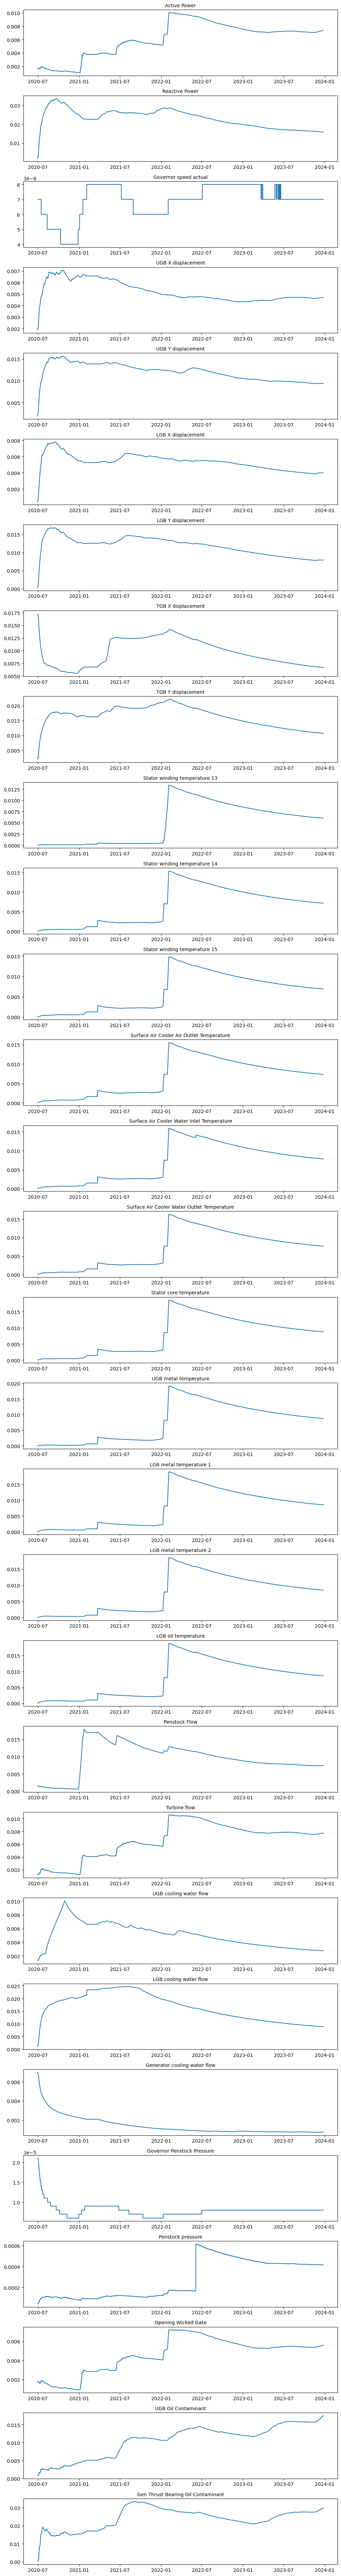

In [6]:
thr_mean = fetch_between_dates('2020-01-01 06:15:00', '2023-12-25 00:00:00', "db/threshold_mean.db", 'DTAAD')

data_timestamp = np.array([convert_timestamp(now_str) for now_str in thr_mean[:, 1]])
thr_mean = thr_mean[:, 2:].astype(float)

fig, axes = plt.subplots(30, 1, figsize=(10, 75))
for i, ax in enumerate(axes):
    ax.plot(data_timestamp, thr_mean[:, i])  # Plot data for each row
    ax.set_title(f'{feature_set[i]}', fontsize=10)  # Set title
plt.tight_layout()
plt.show()

In [ ]:
def percentage2severity(value):
    return (
        0 if 0 <= value < 25 else
        1 if 25 <= value < 50 else
        2 if 50 <= value < 75 else
        3 if 75 <= value <= 100 else
        4
    )

def calcThres_oneModel(current_time, model_now, current_loss):
    temp_severity = {}
    end_date = current_time - timedelta(hours=6)
    start_date = current_time - timedelta(days=1)

    end_date = end_date.strftime('%Y-%m-%d %H:%M:%S')
    start_date = start_date.strftime('%Y-%m-%d %H:%M:%S')

    mean_data = fetch_between_dates(start_date, end_date, "db/threshold_mean.db", model_now)[0, 2:].astype(float)
    m2_data = fetch_between_dates(start_date, end_date, "db/threshold_m2.db", model_now)[0, 2:].astype(float)
    count_data = fetch_between_dates(start_date, end_date, "db/threshold_count.db", model_now)[0, 2:].astype(float)

    for sensor_idx in range(current_loss.shape[-1]):
        now_loss = current_loss[:, sensor_idx]
        std_global = (m2_data[sensor_idx] / (count_data[sensor_idx] - 1))**0.5 if count_data[sensor_idx] > 1 else 0.0

        loss_threb = mean_data[sensor_idx] - (1 * std_global)
        loss_thre0 = mean_data[sensor_idx] + (0 * std_global)
        loss_thre1 = mean_data[sensor_idx] + (1 * std_global)
        loss_thre2 = mean_data[sensor_idx] + (2 * std_global)

        level_1 = (now_loss <= loss_threb)
        level_2 = (now_loss > loss_thre0) & (now_loss <= loss_thre1)
        level_3 = (now_loss > loss_thre1) & (now_loss <= loss_thre2)
        level_4 = (now_loss > loss_thre2)

        x_len = len(now_loss)
        n1 = np.sum(level_1) / x_len
        n2 = np.sum(level_2) / x_len
        n3 = np.sum(level_3) / x_len
        n4 = np.sum(level_4) / x_len

        raw_score = (0.2 * n1 + 2 * n2 + 3 * n3 + 4 * n4)
        normalized_score = max(0.0, ((raw_score - 1) / 3) * 100)
        temp_severity[feature_set[sensor_idx]] = round(float(normalized_score), 2)

    return temp_severity

def calcThres_allModel(current_time_local, thresholds_obj, ypreds_obj, model_array, testD, testO):
    for model_now in model_array:
        model = load_model(model_now, testO.shape[1])
        model.eval()
        torch.zero_grad = True

        if model.name in ['Attention', 'DAGMM', 'USAD', 'MSCRED', 'CAE_M', 'GDN', 'MTAD_GAT', 'MAD_GAN', 'TranAD'] or 'DTAAD' in model.name:
            testD_now = convert_to_windows(testD, model)
        else:
            testD_now = testD
        loss, y_pred = backprop(0, model, testD_now, testO, None, None, training=False)
        
        thresholds_obj[model_now] = calcThres_oneModel(current_time_local, model_now, loss)
        ypreds_obj[model_now] = denormalize3(y_pred, min_a, max_a)

    return thresholds_obj, ypreds_obj

def calc_counterPercentage(threshold_percentages):
    mean_severity_percentage = {}
    for feature_name in feature_set:
        mean_severity_percentage[feature_name] = {"count": 0, "percentage": 0}

    for modex_idx, values_pred in threshold_percentages.items():
        for name_feat, percentage in values_pred.items():
            mean_severity_percentage[name_feat]["count"] = mean_severity_percentage[name_feat]["count"] + 1 if percentage >= 20 else 0
            mean_severity_percentage[name_feat]["percentage"] = mean_severity_percentage[name_feat]["percentage"] + percentage

    for key, value in mean_severity_percentage.items():
        if mean_severity_percentage[key]['count'] >= 2:
            mean_severity_percentage[key]['count'] = round((mean_severity_percentage[key]['count'] / len(model_array)) * 100, 2)
            mean_severity_percentage[key]['percentage'] = (mean_severity_percentage[key]['percentage'] // len(model_array))
            mean_severity_percentage[key]['severity'] = percentage2severity(mean_severity_percentage[key]['percentage'])
        else:
            mean_severity_percentage[key]['count'] = 0
            mean_severity_percentage[key]['percentage'] = 0
            mean_severity_percentage[key]['severity'] = 0

    mean_severity_percentage = dict(sorted(mean_severity_percentage.items(), key=lambda item: item[1]['percentage'], reverse=True))

    # Find Which Model Have Highest Confidence
    counter_feature_plot = {}
    for index, value in mean_severity_percentage.items():
        higher_data = {"model": 0, "percentage": 0}
        for model_idx in threshold_percentages:
            if index in threshold_percentages[model_idx]:
                if higher_data["percentage"] <= threshold_percentages[model_idx][index]:
                    higher_data["model"] = model_idx
                    higher_data["percentage"] = threshold_percentages[model_idx][index]
        
        counter_feature_plot[index] = higher_data['model']

    return mean_severity_percentage, counter_feature_plot

def do_plotSeverityRank(counter_feature_s2, counter_feature_plot, df_timestamp, temp_ypreds, df_feature):
    fig = plt.figure(figsize=(16, 8))
    gs = GridSpec(4, 3, figure=fig)

    feature_index_list = [feature_set.index(feat_name) for feat_name in list(counter_feature_s2.keys())]
    for idx, (feature_index_now) in enumerate(feature_index_list[:4]):
        model_idx_highest = counter_feature_plot[feature_set[feature_index_now]]

        ax = fig.add_subplot(gs[idx, :2])
        ax.plot(df_timestamp, temp_ypreds[model_idx_highest][:, idx], color='blue', label='Prediction')
        ax.plot(df_timestamp, df_feature[:, idx], color='red', label='Original')
        ax.set_title(feature_set[feature_index_now])
        ax.legend() 
        ax.grid(True)

    date_format = DateFormatter("%d/%m/%Y - %H:%M")  # Define the desired format
    plt.gca().xaxis.set_major_formatter(date_format)
    plt.gcf().autofmt_xdate()

    y2 = list(counter_feature_s2.keys())
    x2 = [value['severity'] for value in counter_feature_s2.values()]
    x2_c = [value['count'] for value in counter_feature_s2.values()]

    norm_x2 = [(val - 1) / 3 for val in x2]
    cmap = LinearSegmentedColormap.from_list('severity_colormap', ['green', 'yellow', 'red'])
    colors = [cmap(norm) for norm in norm_x2]

    ax3 = fig.add_subplot(gs[:3, 2])
    bars = ax3.barh(y2, x2, color=colors)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=6))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax3, orientation='vertical', label='Severity')

    for bar, perc in zip(bars, x2_c):
        width = bar.get_width()  # Get the width of the bar
        ax3.text(
            width - 0.1,             # X-coordinate (inside the bar, near the right edge)
            bar.get_y() + bar.get_height() / 2,  # Y-coordinate (center of the bar)
            f"{int(perc)}%",            # Text label (percentage with % sign)
            va='center',           # Vertical alignment
            ha='right',            # Horizontal alignment
            color='black',         # Text color for visibility
            fontsize=9            # Font size
        )
    ax3.invert_yaxis()
    ax3.set_xticks(range(1, 4))
    ax3.set_ylabel("Parameter")
    ax3.set_xlabel("Severity")
    ax3.set_title("Severity Rank")

    #fig.suptitle(f"{df_anomaly_unplaned.values[failure_index_list, 4]}_{df_anomaly_unplaned.values[failure_index_list, 0]}", fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout()
    return fig

TGB Oil Level
Rotor Shaft Current at Lower Generator
TGB Cooling Water


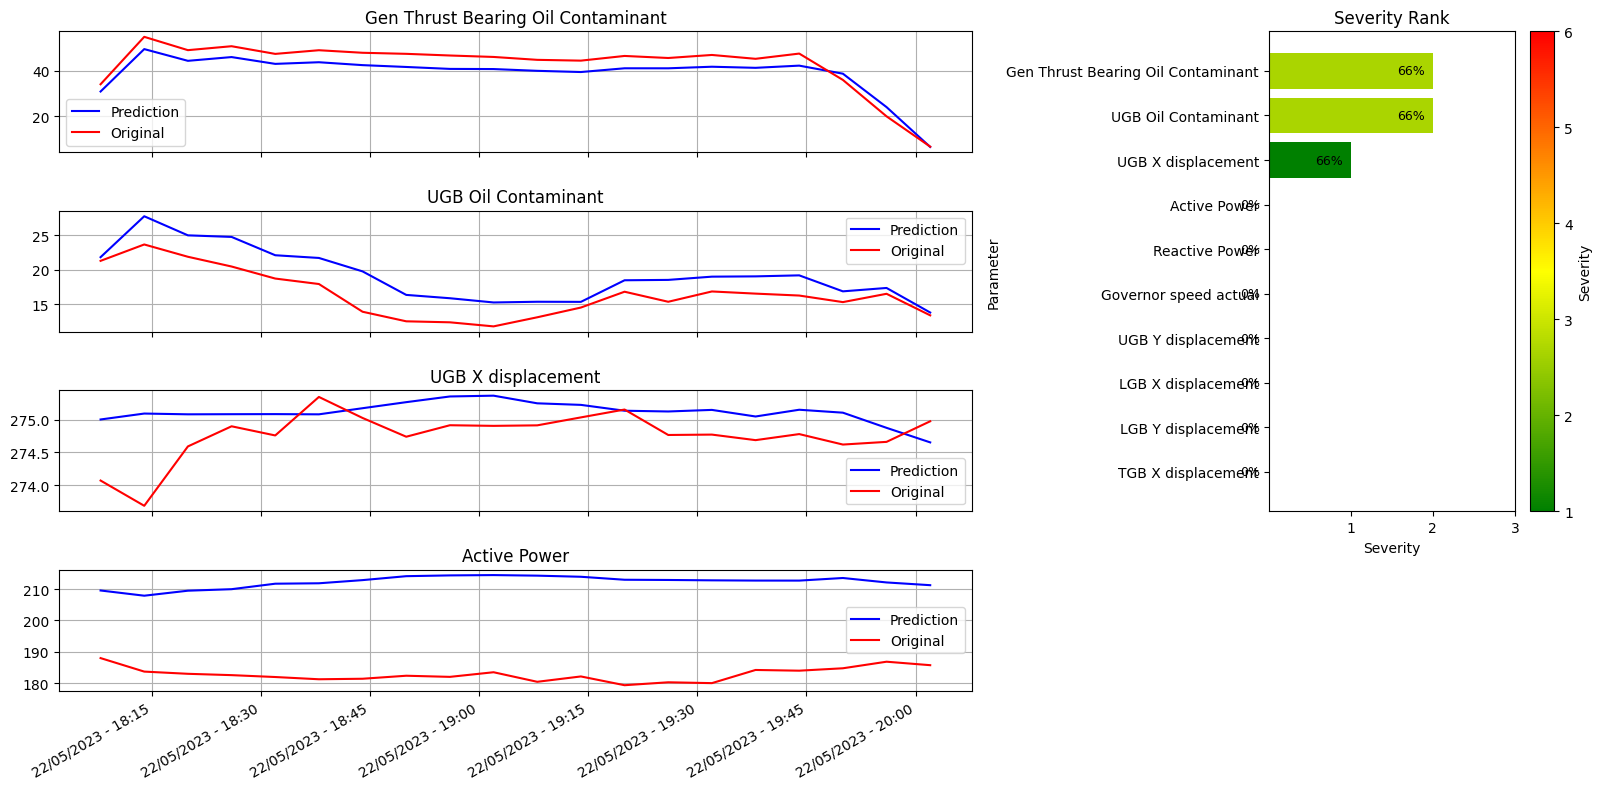

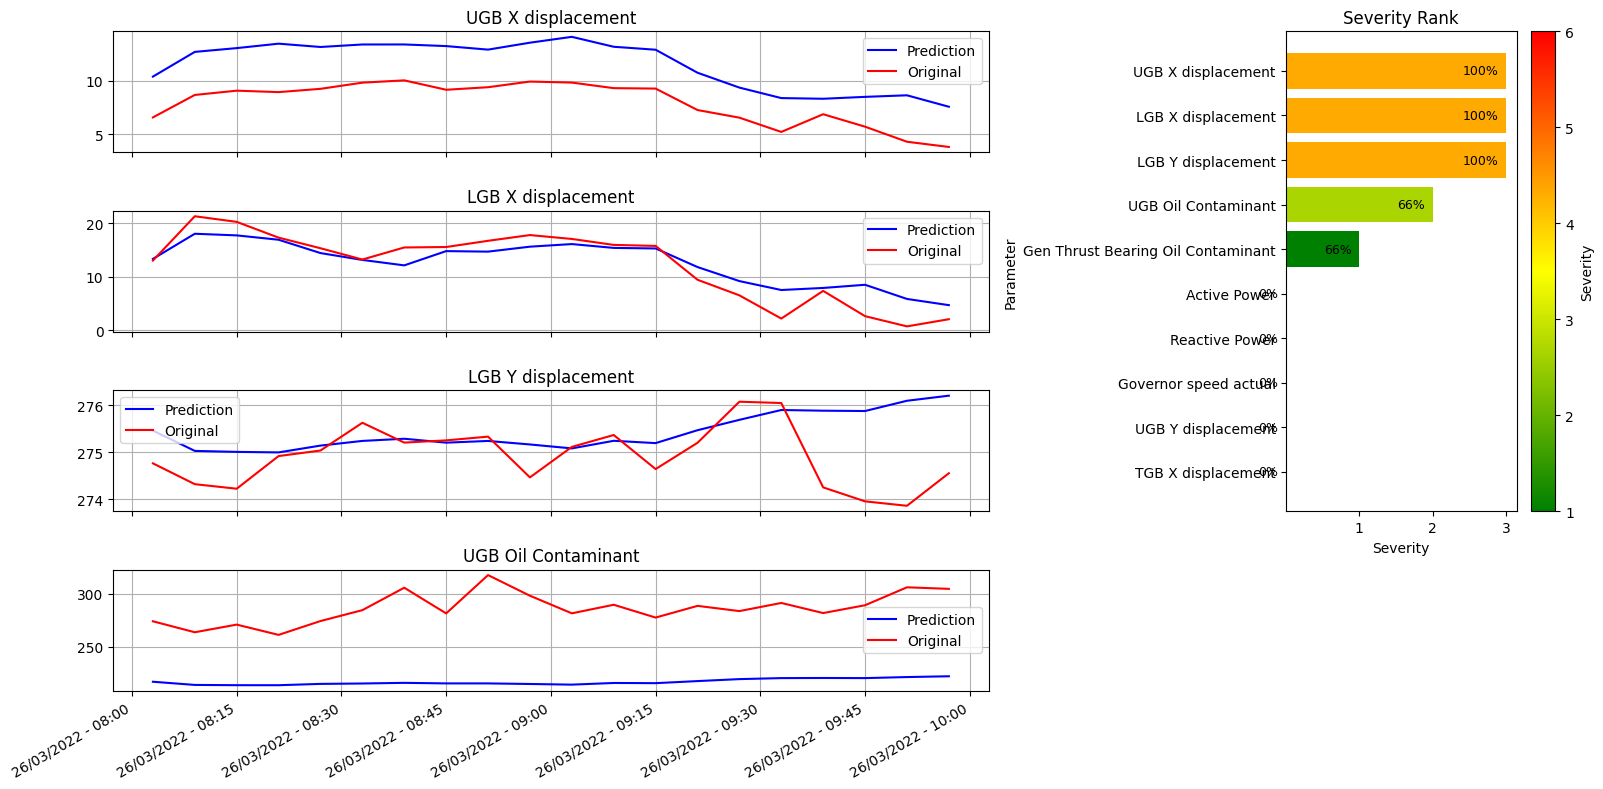

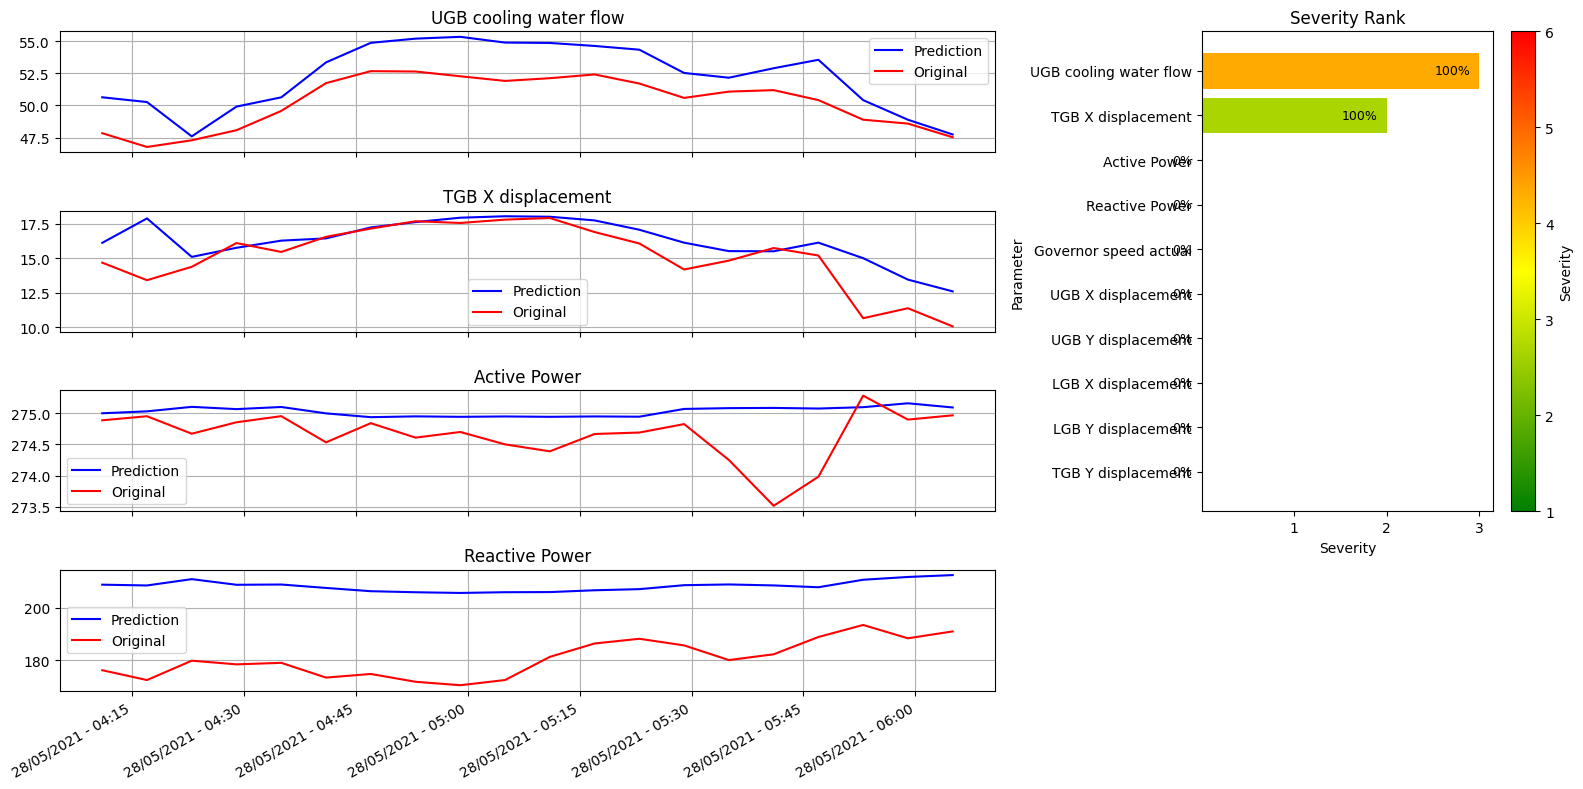

In [221]:
for failure_index_list in range(0, 3):
    threshold_percentages = {}
    ypreds = {}

    end_date_filter = df_anomaly_unplaned.values[failure_index_list, 0] - timedelta(minutes=5)
    start_date_filter =  end_date_filter - timedelta(minutes=measured_horizon)

    print(df_anomaly_unplaned.values[failure_index_list, 4])

    mask = (df_data_withtime['TimeStamp'] > start_date_filter.strftime('%Y-%m-%d %H:%M:%S')) & (df_data_withtime['TimeStamp'] <= end_date_filter.strftime('%Y-%m-%d %H:%M:%S'))
    df_sel = df_data_withtime.loc[mask]
    df_sel = df_sel.reset_index(drop=True)
    
    testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)
    threshold_percentages, ypreds = calcThres_allModel(end_date_filter, threshold_percentages, ypreds, model_array, testD, testO)
    counter_feature_s2, counter_feature_plot = calc_counterPercentage(threshold_percentages)

    df_feature = resample(denormalize3(df_feature, min_a, max_a), 20, axis=0)
    df_timestamp = df_timestamp.dt.floor("min")[::6].values
    for i in model_array:
        ypreds[i] = resample(ypreds[i], 20, axis=0)

    fig = do_plotSeverityRank(dict(list(counter_feature_s2.items())[:10]), counter_feature_plot, df_timestamp, ypreds, df_feature)

In [219]:
end_date_filter

Timestamp('2021-12-04 15:56:00')

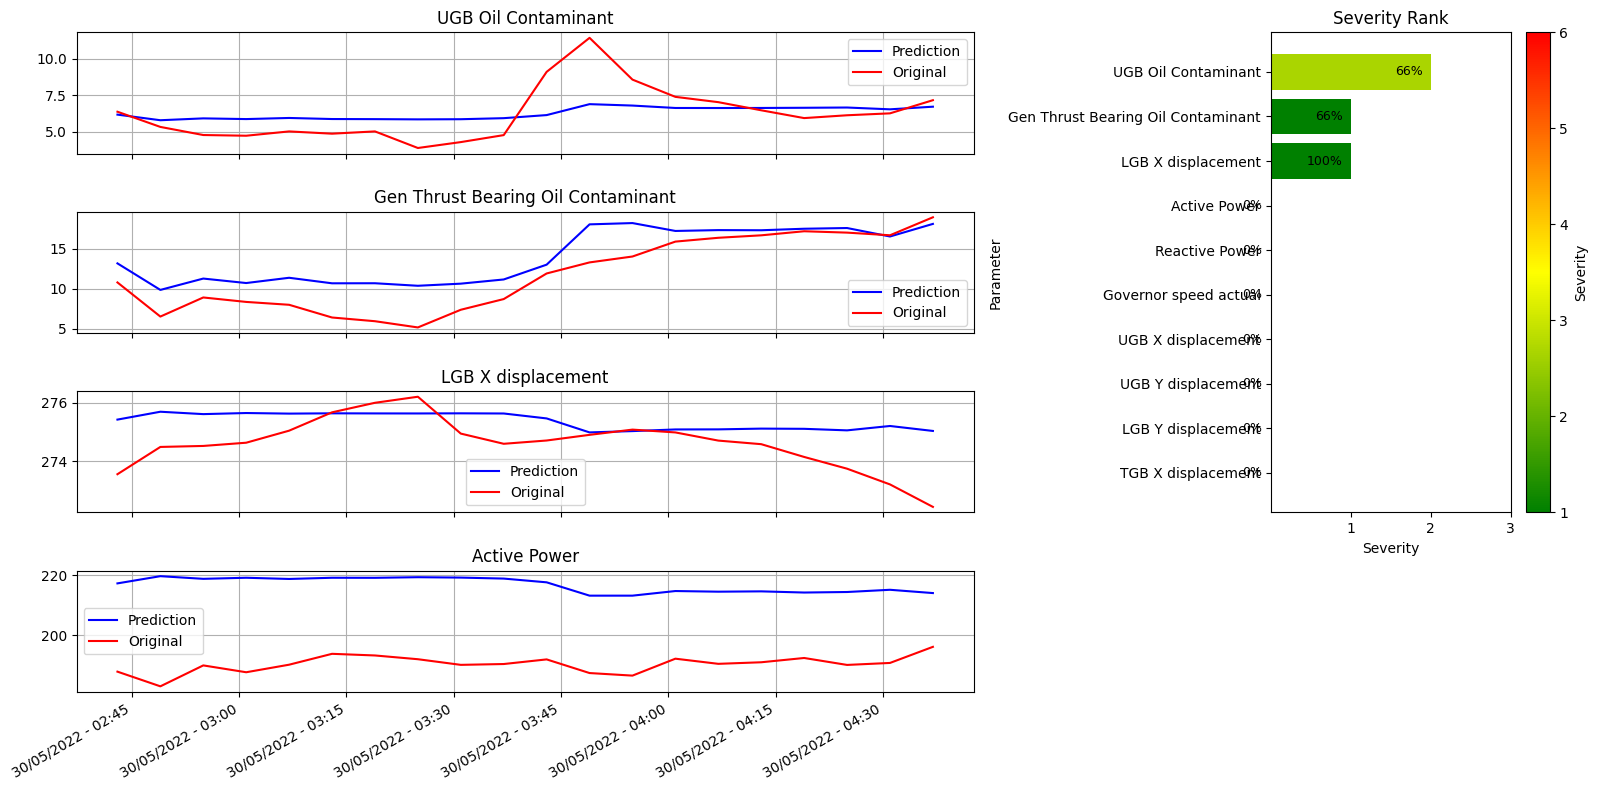

In [243]:
start_range = pd.Timestamp("2020-01-01")
end_range = pd.Timestamp("2023-12-31")

# Generate one random datetime
random_date = pd.to_datetime(
    np.random.uniform(start_range.value, end_range.value, 1)[0]
).floor('T')  # floor to minute

# Calculate the start and end filters
end_date_filter = random_date - timedelta(minutes=5)
start_date_filter = end_date_filter - timedelta(minutes=measured_horizon)

mask = (df_data_withtime['TimeStamp'] > start_date_filter.strftime('%Y-%m-%d %H:%M:%S')) & (df_data_withtime['TimeStamp'] <= end_date_filter.strftime('%Y-%m-%d %H:%M:%S'))
df_sel = df_data_withtime.loc[mask]
df_sel = df_sel.reset_index(drop=True)

testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)
threshold_percentages, ypreds = calcThres_allModel(end_date_filter, threshold_percentages, ypreds, model_array, testD, testO)
counter_feature_s2, counter_feature_plot = calc_counterPercentage(threshold_percentages)

df_feature = resample(denormalize3(df_feature, min_a, max_a), 20, axis=0)
df_timestamp = df_timestamp.dt.floor("min")[::6].values
for i in model_array:
    ypreds[i] = resample(ypreds[i], 20, axis=0)

fig = do_plotSeverityRank(dict(list(counter_feature_s2.items())[:10]), counter_feature_plot, df_timestamp, ypreds, df_feature)


In [188]:
severity_percentage = {}
for model_now in model_array:
    severity_percentage[model_now] = {}

    model = load_model(model_now, testO.shape[1])
    model.eval()
    torch.zero_grad = True
    if model.name in ['Attention', 'DAGMM', 'USAD', 'MSCRED', 'CAE_M', 'GDN', 'MTAD_GAT', 'MAD_GAN', 'TranAD'] or 'DTAAD' in model.name:
        testD_now = convert_to_windows(testD, model)
    else:
        testD_now = testD
    loss, y_pred = backprop(0, model, testD_now, testO, None, None, training=False)

    print(start_date_filter.strftime('%Y-%m-%d %H:%M:%S'))
    print(end_date_filter.strftime('%Y-%m-%d %H:%M:%S'))

    mean_data = fetch_between_dates(start_date_filter.strftime('%Y-%m-%d %H:%M:%S'), end_date_filter.strftime('%Y-%m-%d %H:%M:%S'), "db/threshold_mean.db", model_now)[0, 2:].astype(float)
    m2_data = fetch_between_dates(start_date_filter.strftime('%Y-%m-%d %H:%M:%S'), end_date_filter.strftime('%Y-%m-%d %H:%M:%S'), "db/threshold_m2.db", model_now)[0, 2:].astype(float)
    count_data = fetch_between_dates(start_date_filter.strftime('%Y-%m-%d %H:%M:%S'), end_date_filter.strftime('%Y-%m-%d %H:%M:%S'), "db/threshold_count.db", model_now)[0, 2:].astype(float)
    
    print(mean_data)
    
    for sensor_idx in range(loss.shape[-1]):
        now_loss = loss[:, sensor_idx]
        std_global = (m2_data[sensor_idx] / (count_data[sensor_idx] - 1))**0.5 if count_data[sensor_idx] > 1 else 0.0
        loss_threb = mean_data[sensor_idx] - (1 * std_global)
        loss_thre0 = mean_data[sensor_idx] + (0 * std_global)
        loss_thre1 = mean_data[sensor_idx] + (1 * std_global)
        loss_thre2 = mean_data[sensor_idx] + (2 * std_global)

        level_1 = (now_loss <= loss_threb)
        level_2 = (now_loss > loss_thre0) & (now_loss <= loss_thre1)
        level_3 = (now_loss > loss_thre1) & (now_loss <= loss_thre2)
        level_4 = (now_loss > loss_thre2)

        n1 = np.sum(level_1) / len(now_loss)
        n2 = np.sum(level_2) / len(now_loss)
        n3 = np.sum(level_3) / len(now_loss)
        n4 = np.sum(level_4) / len(now_loss)

        raw_score = (0.2 * n1 + 2 * n2 + 3 * n3 + 4 * n4)
        normalized_score = max(0.0, ((raw_score - 1) / 3) * 100)
        severity_percentage[model_now][feature_set[sensor_idx]] = round(float(normalized_score), 2)

mean_severity_percentage = {}
for feature_name in feature_set:
    mean_severity_percentage[feature_name] = {"count": 0, "percentage": 0}

for modex_idx, values_pred in severity_percentage.items():
    for name_feat, percentage in values_pred.items():
        mean_severity_percentage[name_feat]["count"] = mean_severity_percentage[name_feat]["count"] + 1 if percentage >= 20 else 0
        mean_severity_percentage[name_feat]["percentage"] = mean_severity_percentage[name_feat]["percentage"] + percentage

for key, value in mean_severity_percentage.items():
    if mean_severity_percentage[key]['count'] >= 2:
        mean_severity_percentage[key]['count'] = round((mean_severity_percentage[key]['count'] / len(model_array)) * 100, 2)
        mean_severity_percentage[key]['percentage'] = (mean_severity_percentage[key]['percentage'] // len(model_array))
    else:
        mean_severity_percentage[key]['count'] = 0
        mean_severity_percentage[key]['percentage'] = 0

mean_severity_percentage = dict(sorted(mean_severity_percentage.items(), key=lambda item: item[1]['percentage'], reverse=True))
#mean_severity_percentage

2021-05-28 04:10:00
2021-05-28 06:10:00
[3.7860e-03 2.7225e-02 8.0000e-06 6.3250e-03 1.4109e-02 5.3330e-03
 1.2591e-02 1.2407e-02 1.8954e-02 3.9400e-04 2.2800e-03 2.2910e-03
 2.6260e-03 2.6340e-03 2.7030e-03 2.7550e-03 2.2340e-03 2.5270e-03
 2.2700e-03 2.6200e-03 1.3805e-02 4.1730e-03 7.0060e-03 2.4219e-02
 1.7240e-03 9.0000e-06 1.1800e-04 2.9520e-03 5.6720e-03 1.9980e-02]
2021-05-28 04:10:00
2021-05-28 06:10:00
[2.9540e-03 2.3247e-02 7.0000e-06 5.6440e-03 1.2417e-02 5.1150e-03
 1.2151e-02 1.2141e-02 1.6820e-02 4.8800e-04 2.9000e-03 2.9110e-03
 3.2740e-03 3.2400e-03 3.3120e-03 3.4300e-03 3.0260e-03 3.3340e-03
 3.0420e-03 3.3900e-03 1.7097e-02 3.0920e-03 5.5300e-03 2.1175e-02
 2.2510e-03 7.0000e-06 6.6000e-05 2.2520e-03 3.0710e-03 8.5450e-03]
2021-05-28 04:10:00
2021-05-28 06:10:00
[9.1400e-04 3.0258e-02 5.0000e-06 6.2260e-03 1.4757e-02 6.1540e-03
 1.3939e-02 1.2392e-02 1.8447e-02 1.3600e-04 6.0100e-04 7.2500e-04
 9.5000e-04 8.7800e-04 8.6900e-04 6.3200e-04 2.2700e-04 6.8500e-04
 3.6200

In [ ]:
end_date_filter = convert_timestamp('2021-05-28 06:15:00') - timedelta(days=0) - timedelta(minutes=5)
start_date_filter = end_date_filter - timedelta(minutes=119)
end_date = end_date_filter.strftime('%Y-%m-%d %H:%M:%S')
start_date = start_date_filter.strftime('%Y-%m-%d %H:%M:%S')

original_data = fetch_between_dates(start_date, end_date, "db/original_data.db", "original_data")
data_timestamp = np.array([convert_timestamp(now_str) for now_str in original_data[:, 1]])
original_data = original_data[:, 2:].astype(float)

In [ ]:
for now_feat_index, now_feat in enumerate(feature_set):
    std_global = (m2_data[now_feat_index] / (count_data[now_feat_index] - 1))**0.5 if count_data[now_feat_index] > 1 else 0.0
    loss_threb = mean_data[now_feat_index] - (1 * std_global)
    loss_thre0 = mean_data[now_feat_index] + (0 * std_global)
    loss_thre1 = mean_data[now_feat_index] + (1 * std_global)
    loss_thre2 = mean_data[now_feat_index] + (2 * std_global)
    x = np.arange(len(original_data[:, now_feat_index]))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(original_data[:, now_feat_index], label=f'{now_feat}')
    axes[0].plot(pred_data[:, now_feat_index], label='Model Prediction')
    axes[0].legend()
    axes[0].set_title(f"{now_feat} vs Model Prediction")
    axes[0].set_xlabel("Time Steps")
    axes[0].set_ylabel("Power")
    axes[0].grid(True)

    axes[1].plot(loss_calc[:, now_feat_index], label='Loss Calc')
    axes[1].fill_between(x=x, y1=loss_thre0, y2=loss_threb, color='green', alpha=.2)
    axes[1].fill_between(x=x, y1=loss_thre1, y2=loss_thre0, color='yellow', alpha=.2)
    axes[1].fill_between(x=x, y1=loss_thre2, y2=loss_thre1, color='red', alpha=.2)
    axes[1].set_title("Loss vs Threshold")
    axes[1].set_xlabel("Time Steps")
    axes[1].set_ylabel("Loss Value")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def compute_ewma(errors, alpha=0.3):
    ewma = np.zeros_like(errors)
    ewma[0] = errors[0]
    for t in range(1, len(errors)):
        ewma[t] = alpha * errors[t] + (1 - alpha) * ewma[t - 1]
    return ewma

def get_sequences(ea_indices):
    if len(ea_indices) == 0:
        return []

    sequences = []
    current_seq = [ea_indices[0]]

    for idx in ea_indices[1:]:
        if idx == current_seq[-1] + 1:
            current_seq.append(idx)
        else:
            sequences.append(current_seq)
            current_seq = [idx]

    sequences.append(current_seq)
    return sequences

def select_dynamic_threshold(es, z_range=range(2, 11)):
    best_score = -np.inf
    best_thresh = None
    mu_es = np.mean(es)
    sigma_es = np.std(es)

    for z in z_range:
        epsilon = mu_es + z * sigma_es
        below_eps = es[es < epsilon]
        if len(below_eps) == 0:
            continue

        delta_mu = mu_es - np.mean(below_eps)
        delta_sigma = sigma_es - np.std(below_eps)

        ea_indices = np.where(es > epsilon)[0]
        ea = es[ea_indices]
        eseq = get_sequences(ea_indices)

        penalty = len(ea) + len(eseq) ** 2
        score = (delta_mu / mu_es + delta_sigma / sigma_es) / (penalty + 1e-6)  # avoid div by zero

        if score > best_score:
            best_score = score
            best_thresh = epsilon

    return best_thresh

def score_anomalies(es, epsilon, ea_indices):
    mu = np.mean(es)
    sigma = np.std(es)
    sequences = get_sequences(ea_indices)

    scores = []
    for seq in sequences:
        max_val = np.max(es[seq])
        score = (max_val - epsilon) / (mu + sigma)
        scores.append((seq, score))
    return scores


def detect_anomalies(errors, alpha=0.3, z_range=range(2, 11)):
    es = compute_ewma(errors, alpha=alpha)
    epsilon = select_dynamic_threshold(es, z_range)

    if epsilon is None:
        return [], []

    anomaly_indices = np.where(es > epsilon)[0]
    anomaly_scores = score_anomalies(es, epsilon, anomaly_indices)

    return anomaly_scores, epsilon

In [ ]:
es = compute_ewma(loss_calc, alpha=0.3)
z_range=range(2, 11)
epsilon = select_dynamic_threshold(es, z_range)
anomaly_indices = np.where(es > epsilon)[0]
anomaly_scores = score_anomalies(es, epsilon, anomaly_indices)

plt.figure(figsize=(12, 4))
plt.plot(loss_calc[:, now_feat_index], label='Loss Calc')
plt.plot(es[:, now_feat_index], label='Loss ES')
plt.axhline(y=epsilon, color='orange', linestyle='--')

for seq_indices, score in anomaly_scores:
    if not seq_indices:
        continue

    seq_indices = np.array(seq_indices)
    plt.plot(seq_indices, es[seq_indices, now_feat_index], color='red', linewidth=2)
    max_idx = seq_indices[np.argmax(es[seq_indices, now_feat_index])]
    plt.text(max_idx, es[max_idx, now_feat_index], f"{score:.2f}", color='red', fontsize=9, ha='center')

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
failure_index_list = 1
threshold_percentages = {}
temp_ypreds = {}

end_date_filter = df_anomaly_unplaned.values[failure_index_list, 0] - timedelta(minutes=20)
start_date_filter =  end_date_filter - timedelta(minutes=measured_horizon)

mask = (df_data_withtime['TimeStamp'] > start_date_filter.strftime('%Y-%m-%d %H:%M:%S')) & (df_data_withtime['TimeStamp'] <= end_date_filter.strftime('%Y-%m-%d %H:%M:%S'))
df_sel = df_data_withtime.loc[mask]
df_sel = df_sel.reset_index(drop=True)

testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)

model_now = "TranAD"
model = load_model(model_now, testO.shape[1])
model.eval()
torch.zero_grad = True

if model.name in ['Attention', 'DAGMM', 'USAD', 'MSCRED', 'CAE_M', 'GDN', 'MTAD_GAT', 'MAD_GAN', 'TranAD'] or 'DTAAD' in model.name:
    testD_now = convert_to_windows(testD, model)
else:
    testD_now = testD

In [ ]:
end_date_filter = df_anomaly_unplaned.values[failure_index_list, 0] - timedelta(minutes=5)
start_date_filter =  end_date_filter - timedelta(minutes=measured_horizon)

mask = (df_data_withtime['TimeStamp'] > start_date_filter.strftime('%Y-%m-%d %H:%M:%S')) & (df_data_withtime['TimeStamp'] <= end_date_filter.strftime('%Y-%m-%d %H:%M:%S'))
df_sel = df_data_withtime.loc[mask]
df_sel = df_sel.reset_index(drop=True)

testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)

if model.name in ['Attention', 'DAGMM', 'USAD', 'MSCRED', 'CAE_M', 'GDN', 'MTAD_GAT', 'MAD_GAN', 'TranAD'] or 'DTAAD' in model.name:
    testD_now = convert_to_windows(testD, model)
else:
    testD_now = testD

In [ ]:
loss_global = {}
ypred_global = {}

for model_now in model_array:
    mean_global = {}
    loss, y_pred = backprop(0, model, testD_now, testO, None, None, training=False)
    
    loss_global[model_now] = loss
    ypred_global[model_now] = y_pred

In [ ]:
y_pred = denormalize3(y_pred, min_a, max_a)
df_feature = denormalize3(df_feature, min_a, max_a)

In [ ]:
feature_set

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

now_feat = 'LGB Y displacement'
now_feat_index = feature_set.index(now_feat)

std_global = (M2_global[now_feat] / (n_total[now_feat] - 1))**0.5 if n_total[now_feat] > 1 else 0.0
loss_thre = mean_global[now_feat] #+ std_global

axes[0].plot(df_feature[[now_feat]].values, label=f'{now_feat} (sampled)')
axes[0].plot(y_pred[:, now_feat_index], label='Model Prediction')
axes[0].legend()
axes[0].set_title(f"{now_feat} vs Model Prediction")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Power")
axes[0].grid(True)

axes[1].plot(loss[:, now_feat_index], label='Loss')
axes[1].axhline(y=loss_thre, color='r', linestyle='-', label='Threshold')
axes[1].legend()
axes[1].set_title("Loss vs Threshold")
axes[1].set_xlabel("Time Steps")
axes[1].set_ylabel("Loss Value")
axes[1].grid(True)

plt.tight_layout()
plt.show()